In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Hierarchical_Interval_Halving import *
from optimal_hyperparameter import AMethod

### Reading the data from the path. In the UI, the user will upload a file instead.

In [14]:
ts_arr = pd.read_csv('../Code- Segmentation Pipeline and Results/Datasets_csv/Pressure/Sheet1.csv')['PSPCKL'].dropna().to_numpy() 
ts_name = 'PSPCKL- Sheet 1'

### Hyperparameters can be hardcoded in the UI code for now. Later on, we can modify the code to take this input from user.

In [3]:
var_fracs_tuning = np.linspace(1e-2, 2e-1, num = 10)
window_lens_tuning = np.linspace(10, 200, num = 10, dtype = int)

### Functions for performing hyperparameter tuning and returning the best model

In [4]:
alpha_f_test_val = 0.05

def hyperparam_tuning_var(time_series, series_name, var_data, curr_frac):
    model = Hierarchical_Interval_Halving(noise_err = curr_frac*var_data, min_window_len = window_lens_tuning[0], degrees = [0,1], \
                                      title = series_name, suppress_print = True, alpha_f_test = alpha_f_test_val)
    seg_count = model.train_model(time_series)
    return seg_count
    
def hyperparam_tuning_window(time_series, series_name, var_data, curr_window, opt_frac):
    model = Hierarchical_Interval_Halving(noise_err = opt_frac*var_data, min_window_len = int(curr_window), degrees = [0,1], \
                                      title = series_name, suppress_print = True, alpha_f_test = alpha_f_test_val)
    seg_count = model.train_model(time_series)
    return seg_count

def segmentation_analysis(time_series, series_name):
    err_data = np.var(time_series)
    ###########################################
    # Parameter tuning for variance fraction
    ###########################################
    
    count_segments_var = np.array([hyperparam_tuning_var(time_series, series_name, err_data, frac)
                                   for frac in var_fracs_tuning])
    
    opt_var_frac = var_fracs_tuning[AMethod().get_elbow_point(var_fracs_tuning, count_segments_var)]
    ###########################################
    # Parameter tuning for window length
    ###########################################          
    count_segments_window = np.array([hyperparam_tuning_window(time_series, series_name, 
                                     err_data, tuning_len, opt_var_frac) for tuning_len in window_lens_tuning])
    
    opt_window_len = window_lens_tuning[AMethod().get_elbow_point(window_lens_tuning, count_segments_window)]
    
    ###########################################
    # Fitting the optimal model
    ###########################################
    model = Hierarchical_Interval_Halving(noise_err = opt_var_frac*err_data, ylabel = series_name.split('_')[-1], \
                                      degrees = [0,1], min_window_len = opt_window_len, title = series_name, 
                                      suppress_print = True, alpha_f_test = alpha_f_test_val)
    model.train_model(time_series)        
    
    return model

### Train the model

In [15]:
seg_model = segmentation_analysis(ts_arr, ts_name)

### Plot the results- (TO BE DISPLAYED IN THE UI)

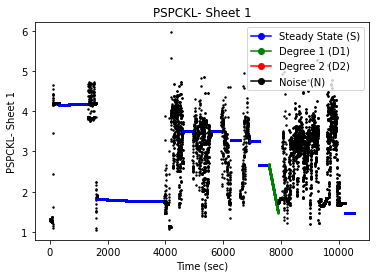

In [16]:
plt.figure()
seg_model.plot_data_pred_intervals(linestyle = 'dotted', point_size = 2)
#plt.savefig('./filname.png', dpi = 1000)
plt.show()

### TO BE PRINTED IN THE UI

In [17]:
seg_model.return_intervals()

[([0, 329], 'Noise (N)'),
 ([330, 1316], 'Steady State (S)'),
 ([1317, 1645], 'Noise (N)'),
 ([1646, 3948], 'Steady State (S)'),
 ([3949, 4606], 'Noise (N)'),
 ([4607, 4935], 'Steady State (S)'),
 ([4936, 5594], 'Noise (N)'),
 ([5595, 5923], 'Steady State (S)'),
 ([5924, 6252], 'Noise (N)'),
 ([6253, 6581], 'Steady State (S)'),
 ([6582, 6910], 'Noise (N)'),
 ([6911, 7568], 'Steady State (S)'),
 ([7569, 7897], 'Degree 1 (D1)'),
 ([7898, 10200], 'Noise (N)'),
 ([10201, 10529], 'Steady State (S)')]